In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR#support vector regressor
import sklearn.metrics as mt
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
hr=pd.read_csv(r'C:\Users\Arbiya\Downloads\framingham.csv\Lab 21 House_Rent_Dataset.csv')

In [4]:
hr=hr.drop(['Floor','Area Locality'],axis=1)
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Area Type', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='str')

In [5]:
#Splitting
X= hr.drop(columns='Rent')
y= hr['Rent']

In [6]:
#Encoding - L00 encoder
encoder = ce.LeaveOneOutEncoder(return_df=True)

In [7]:
X= encoder.fit_transform(X,y)

In [8]:
X.head()

,Posted On,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,49986.301370,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,33369.521739,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,22156.603774,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,36085.321101,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,15857.142857,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [9]:
scaler = MinMaxScaler()
X=scaler.fit_transform(X)

In [10]:
X

array([[0.45509995, 0.2       , 0.13642053, ..., 0.01795978, 0.11111111,
        0.00321938],
       [0.27059207, 0.2       , 0.09887359, ..., 0.01780886, 0.        ,
        0.00316481],
       [0.14608709, 0.2       , 0.12390488, ..., 0.01785413, 0.        ,
        0.00318118],
       ...,
       [0.35249127, 0.4       , 0.21777222, ..., 0.01758247, 0.22222222,
        0.99965557],
       [0.43311387, 0.4       , 0.1864831 , ..., 0.99558704, 0.11111111,
        0.99954076],
       [0.11689738, 0.2       , 0.12390488, ..., 0.58744851, 0.11111111,
        0.00319209]], shape=(4746, 9))

In [11]:
X_df= pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7,8
0,0.455100,0.2,0.136421,0.273162,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.270592,0.2,0.098874,0.273074,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.146087,0.2,0.123905,0.273100,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.300748,0.2,0.098874,0.273162,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.076140,0.2,0.105131,0.999941,0.004452,0.009593,0.587919,0.000000,0.003233


In [13]:

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,
                                                   random_state=42)            

In [14]:
X_train.shape, X_test.shape

((3796, 9), (950, 9))

In [15]:
#train
lr=LinearRegression()

In [17]:
model=lr.fit(X_train,y_train)

In [18]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 5424.05, 27397.92,275866.58,...,-10872.08, 82376.63, 11429.55]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.21e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[36.43,21.12,19.56,...,10.91, 3.55, 2.52]"


In [19]:
#prediction
y_pred=model.predict(X_test)
y_pred

array([ 2.58989262e+04,  1.54654610e+04,  6.17905654e+04,  6.66646689e+04,
        1.01220978e+05,  4.02706177e+04,  7.38381514e+04,  1.29215310e+04,
        1.73402759e+05,  7.82877176e+03, -4.90218521e+02,  5.00509399e+03,
        3.52849265e+04,  1.14700951e+04,  2.51361186e+04,  4.25546938e+04,
        1.23824715e+05,  1.11473223e+03,  1.48993052e+04,  7.56691472e+04,
        5.16486720e+04, -1.14705565e+04,  6.02547890e+04,  2.81649822e+04,
        1.45421684e+05, -1.42075173e+04, -7.27230702e+03,  5.70716527e+04,
       -1.79536429e+04,  2.65409097e+02, -1.34446900e+04, -4.57754742e+03,
       -8.49461816e+02,  2.16744925e+04,  3.90462306e+04,  4.88433855e+04,
       -4.41864050e+03, -1.52075838e+04,  2.36199893e+04, -5.00451400e+03,
        2.06122043e+04,  1.87414428e+05,  1.80389025e+04, -9.64883709e+03,
        8.08389361e+04,  1.21415821e+04,  7.56208888e+04,  1.00183996e+05,
        1.98064716e+05,  3.29813027e+04,  1.41481235e+04,  6.29444549e+04,
        2.13259267e+04,  

In [21]:
mse=mt.mean_squared_error(y_test,y_pred)
mae=mt.mean_absolute_error(y_test,y_pred)
r2=mt.r2_score(y_test,y_pred)
print(f'The mean squared error is {mse}')
print(f'The mean absolute error is {mae}')
print(f'The mean R squared Score is {r2}')

The mean squared error is 1936735071.3438056
The mean absolute error is 22517.001214504366
The mean R squared Score is 0.5140402091518004


In [22]:
dtr = DecisionTreeRegressor()
model_dtr=dtr.fit(X_train,y_train)
dtr_pred= model_dtr.predict(X_test)
dtr_pred


array([ 16000.,  12000.,  28000.,   8000.,  46000.,  17000.,  57000.,
         9500., 400000.,  15000.,  10000.,  12000.,  26000.,  16000.,
        15000.,   8500., 140000.,  12000.,   6000.,  60000.,  38000.,
         7500.,  23000.,  14000., 260000.,   5000.,   6000.,  16500.,
         6500.,  15000.,   5000.,  14000.,   5000.,  12000.,  25000.,
        25000.,   7500.,   6000.,  17000.,   7000.,  13000., 330000.,
        14000.,   6000.,  60000.,  14000.,  32000.,  65000., 350000.,
        15000.,  11000.,  35000.,  18000.,  12000.,  65000., 130000.,
        35000.,  40000.,   9000.,   9000.,  18000.,   5000., 130000.,
        12000.,  50000.,  20000.,  18000.,  15500.,  35000.,  30000.,
        13000.,  24000., 110000.,   7000.,  25000.,  35000.,  12000.,
        52000.,  35000.,  28000.,  14000.,  10000.,  34000.,  10000.,
        12000.,  45000.,  35000.,  18000.,  25000.,  27000., 260000.,
        35000.,  24000., 120000.,  13000.,  12000.,  11000.,   7000.,
        20000.,  240

In [23]:
mse_dtr=mt.mean_squared_error(y_test,dtr_pred)
mae_dtr=mt.mean_absolute_error(y_test,dtr_pred)
r2_dtr=mt.r2_score(y_test,dtr_pred)
print(f'The mean squared error is {mse_dtr}')
print(f'The mean absolute error is {mae_dtr}')
print(f'The mean R squared Score is {r2_dtr}')

The mean squared error is 255757248.4063158
The mean absolute error is 1104.635789473684
The mean R squared Score is 0.9358261536219267


In [25]:
rfr=RandomForestRegressor(n_estimators=100)
model_rfr=rfr.fit(X_train,y_train)
rfr_pred=model_rfr.predict(X_test)

In [26]:
mse_rfr=mt.mean_squared_error(y_test,rfr_pred)
mae_rfr=mt.mean_absolute_error(y_test,rfr_pred)
r2_rfr=mt.r2_score(y_test,rfr_pred)
print(f'The mean squared error is {mse_rfr}')
print(f'The mean absolute error is {mae_rfr}')
print(f'The mean R squared Score is {r2_rfr}')

The mean squared error is 267358882.7409624
The mean absolute error is 1452.6096315789473
The mean R squared Score is 0.9329151061182275


In [34]:
svr = SVR()
model_svr=svr.fit(X_train,y_train)
svr_pred=model_svr.predict(X_test)
svr_pred

array([15706.21583695, 16016.11984612, 16274.23255505, 16103.73248046,
       16455.97618413, 16466.85959223, 16625.74321254, 15756.29621082,
       16605.84390174, 15760.34815471, 15736.06855892, 16006.31791979,
       16525.0243097 , 16424.13053293, 15914.00025665, 16136.73622793,
       16528.61139275, 15658.7731629 , 16038.93285017, 16189.04919712,
       16489.72270661, 15834.42099453, 16595.1320813 , 16036.91564877,
       16400.85842302, 15943.71938961, 15741.54036684, 15918.78321795,
       15804.9801574 , 16319.5290692 , 15651.19661866, 15947.94250129,
       15854.02571656, 15938.79051739, 15947.21843068, 16082.64806139,
       15848.6009654 , 15654.28429558, 15759.37534546, 15663.4509445 ,
       15751.85361808, 16649.03899517, 16010.41173677, 15663.52130552,
       16612.95679104, 15760.08970557, 16691.53227862, 16640.04386943,
       16649.94451858, 16020.14265243, 15865.63483248, 16180.60163724,
       16017.60451117, 15813.45047217, 16172.82789474, 16682.96358167,
      

In [35]:
mse_svr=mt.mean_squared_error(y_test,svr_pred)
mae_svr=mt.mean_absolute_error(y_test,svr_pred)
r2_svr=mt.r2_score(y_test,svr_pred)
print(f'The mean squared error is {mse_svr}')
print(f'The mean absolute error is {mae_svr}')
print(f'The mean R squared Score is {r2_svr}')

The mean squared error is 4299944333.835436
The mean absolute error is 24064.565956614355
The mean R squared Score is -0.07892921445352785


## Machine Learning - Classification Alogithm

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [38]:
wdf=pd.read_csv(r"C:\Users\Arbiya\Downloads\framingham.csv\Lab 22 winequality-red.csv")

In [41]:
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [40]:
wdf.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [42]:
wdf.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [44]:
wdf.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [10]:
wdf=pd.read_csv(r"C:\Users\Arbiya\Downloads\framingham.csv\Lab 22 winequality-red.csv")

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


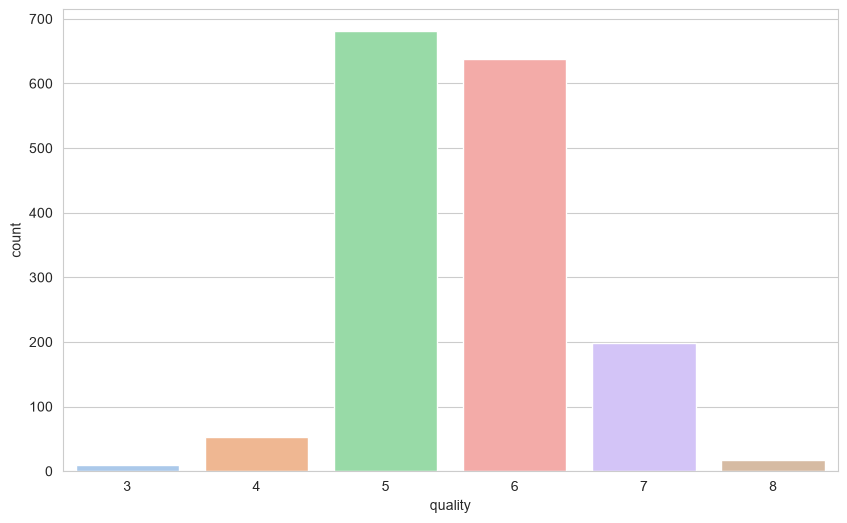

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(style='whitegrid')
print(wdf['quality'].value_counts())

# ✅ Correct way to set figure size
fig = plt.figure(figsize=(10,6))

sns.countplot(data=wdf, x='quality', palette='pastel')
plt.show()


In [18]:
num_cols = wdf.select_dtypes(include='number')
num_cols.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Axes: >

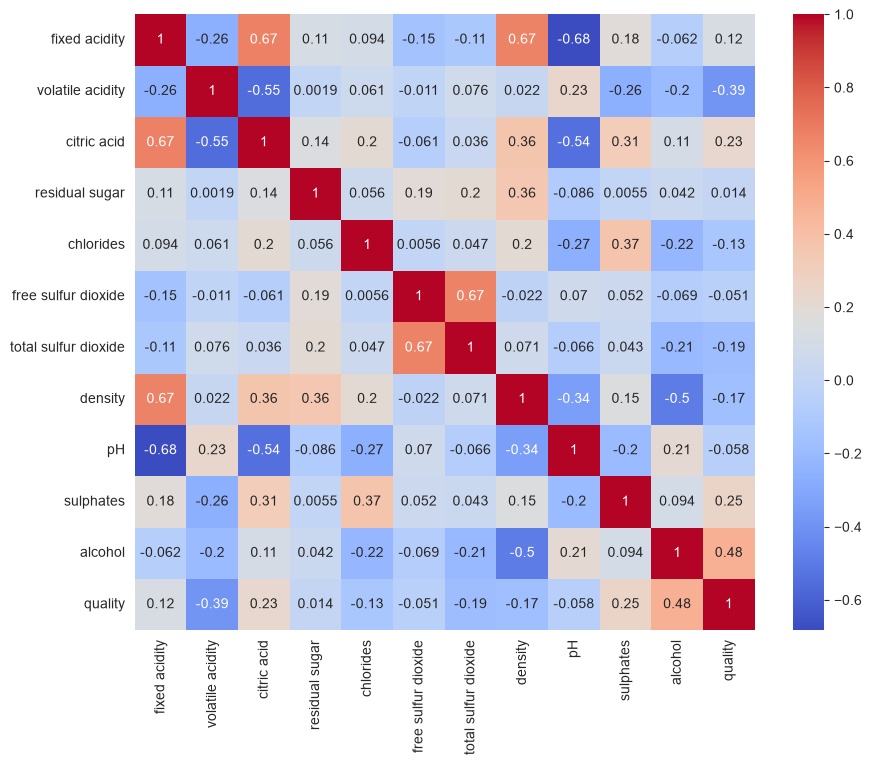

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), annot=True,cmap='coolwarm')

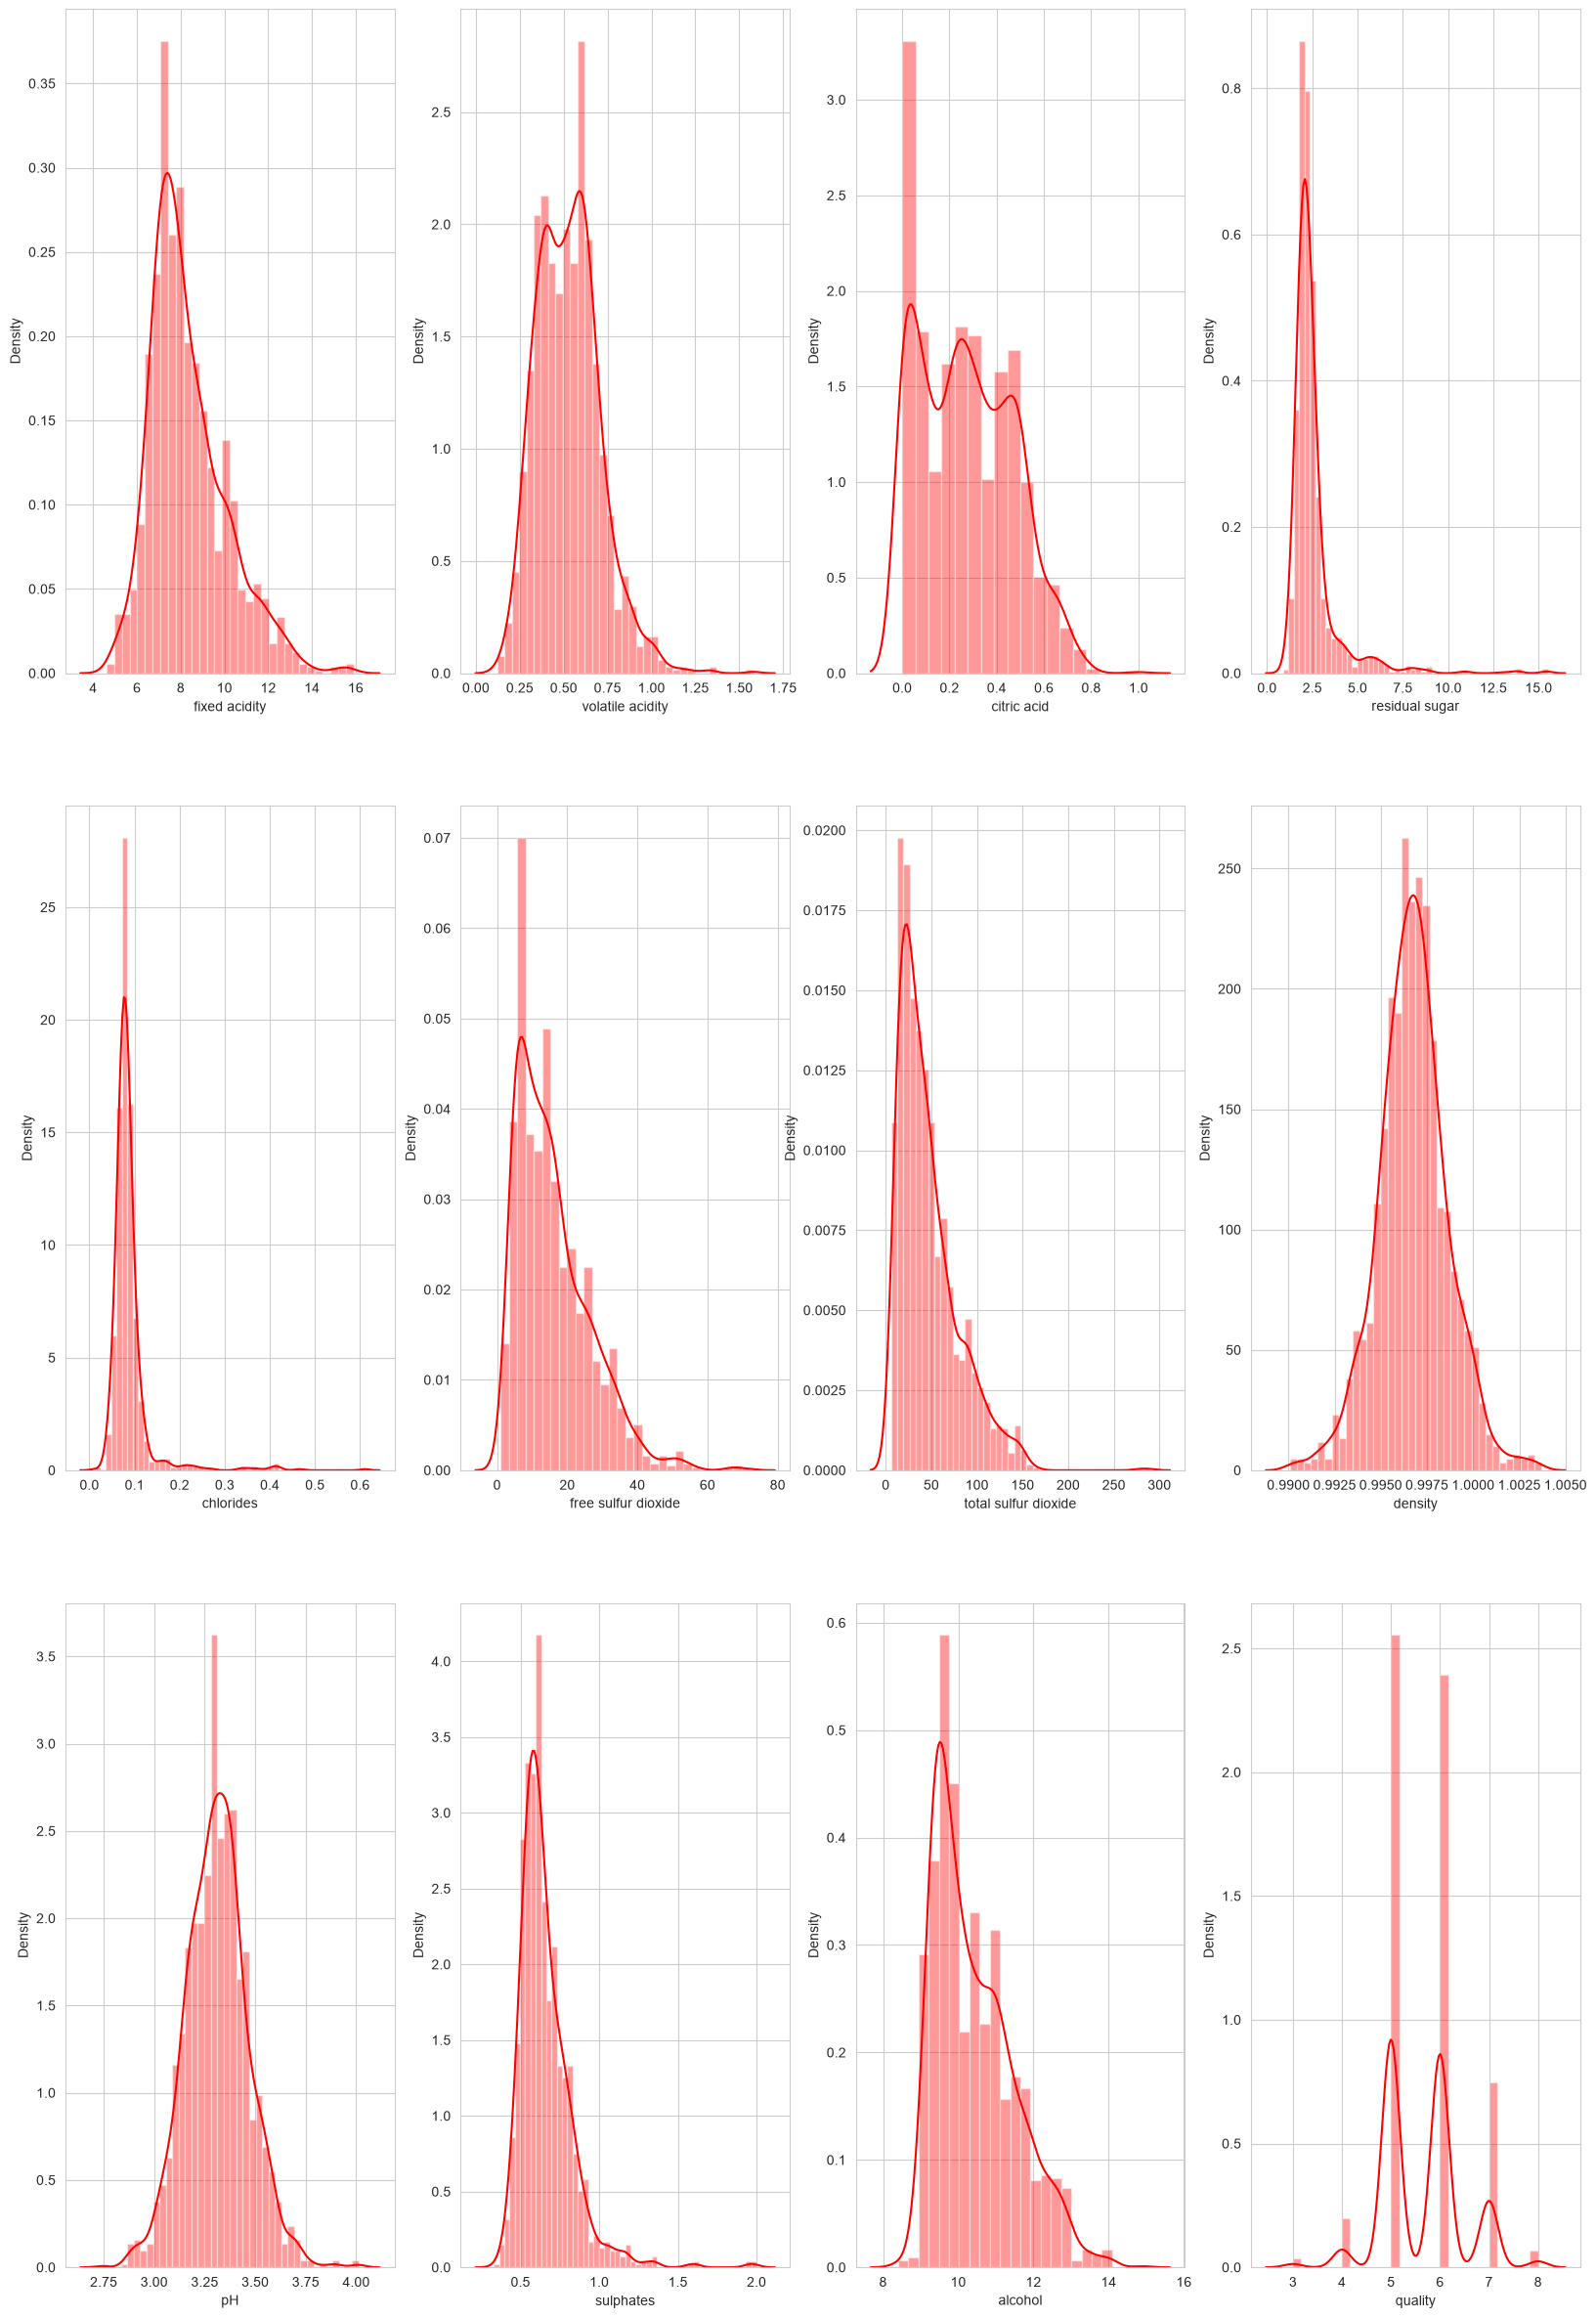

In [26]:
color=sns.color_palette('pastel')

fig,ax1=plt.subplots(3,4,figsize=(20,30))
k=0
columns=list(wdf.columns)
for i in range(3):
    for j in range(4):
     sns.distplot(wdf[columns[k]],ax=ax1[i][j],color='red')
     k=k+1
plt.show()

In [30]:
#log transformation
def log_transformation(col):
    return np.log(col.iloc[0])

In [31]:
wdf['residual sugar']=wdf[['residual sugar']].apply(log_transformation,axis=1)
wdf['chlorides']=wdf[['chlorides']].apply(log_transformation,axis=1)
wdf['free sulfur dioxide']=wdf[['free sulfur dioxide']].apply(log_transformation,axis=1)
wdf['total sulfur dioxid']=wdf[['total sulfur dioxide']].apply(log_transformation,axis=1)
wdf['sulphates']=wdf[['sulphates']].apply(log_transformation,axis=1)

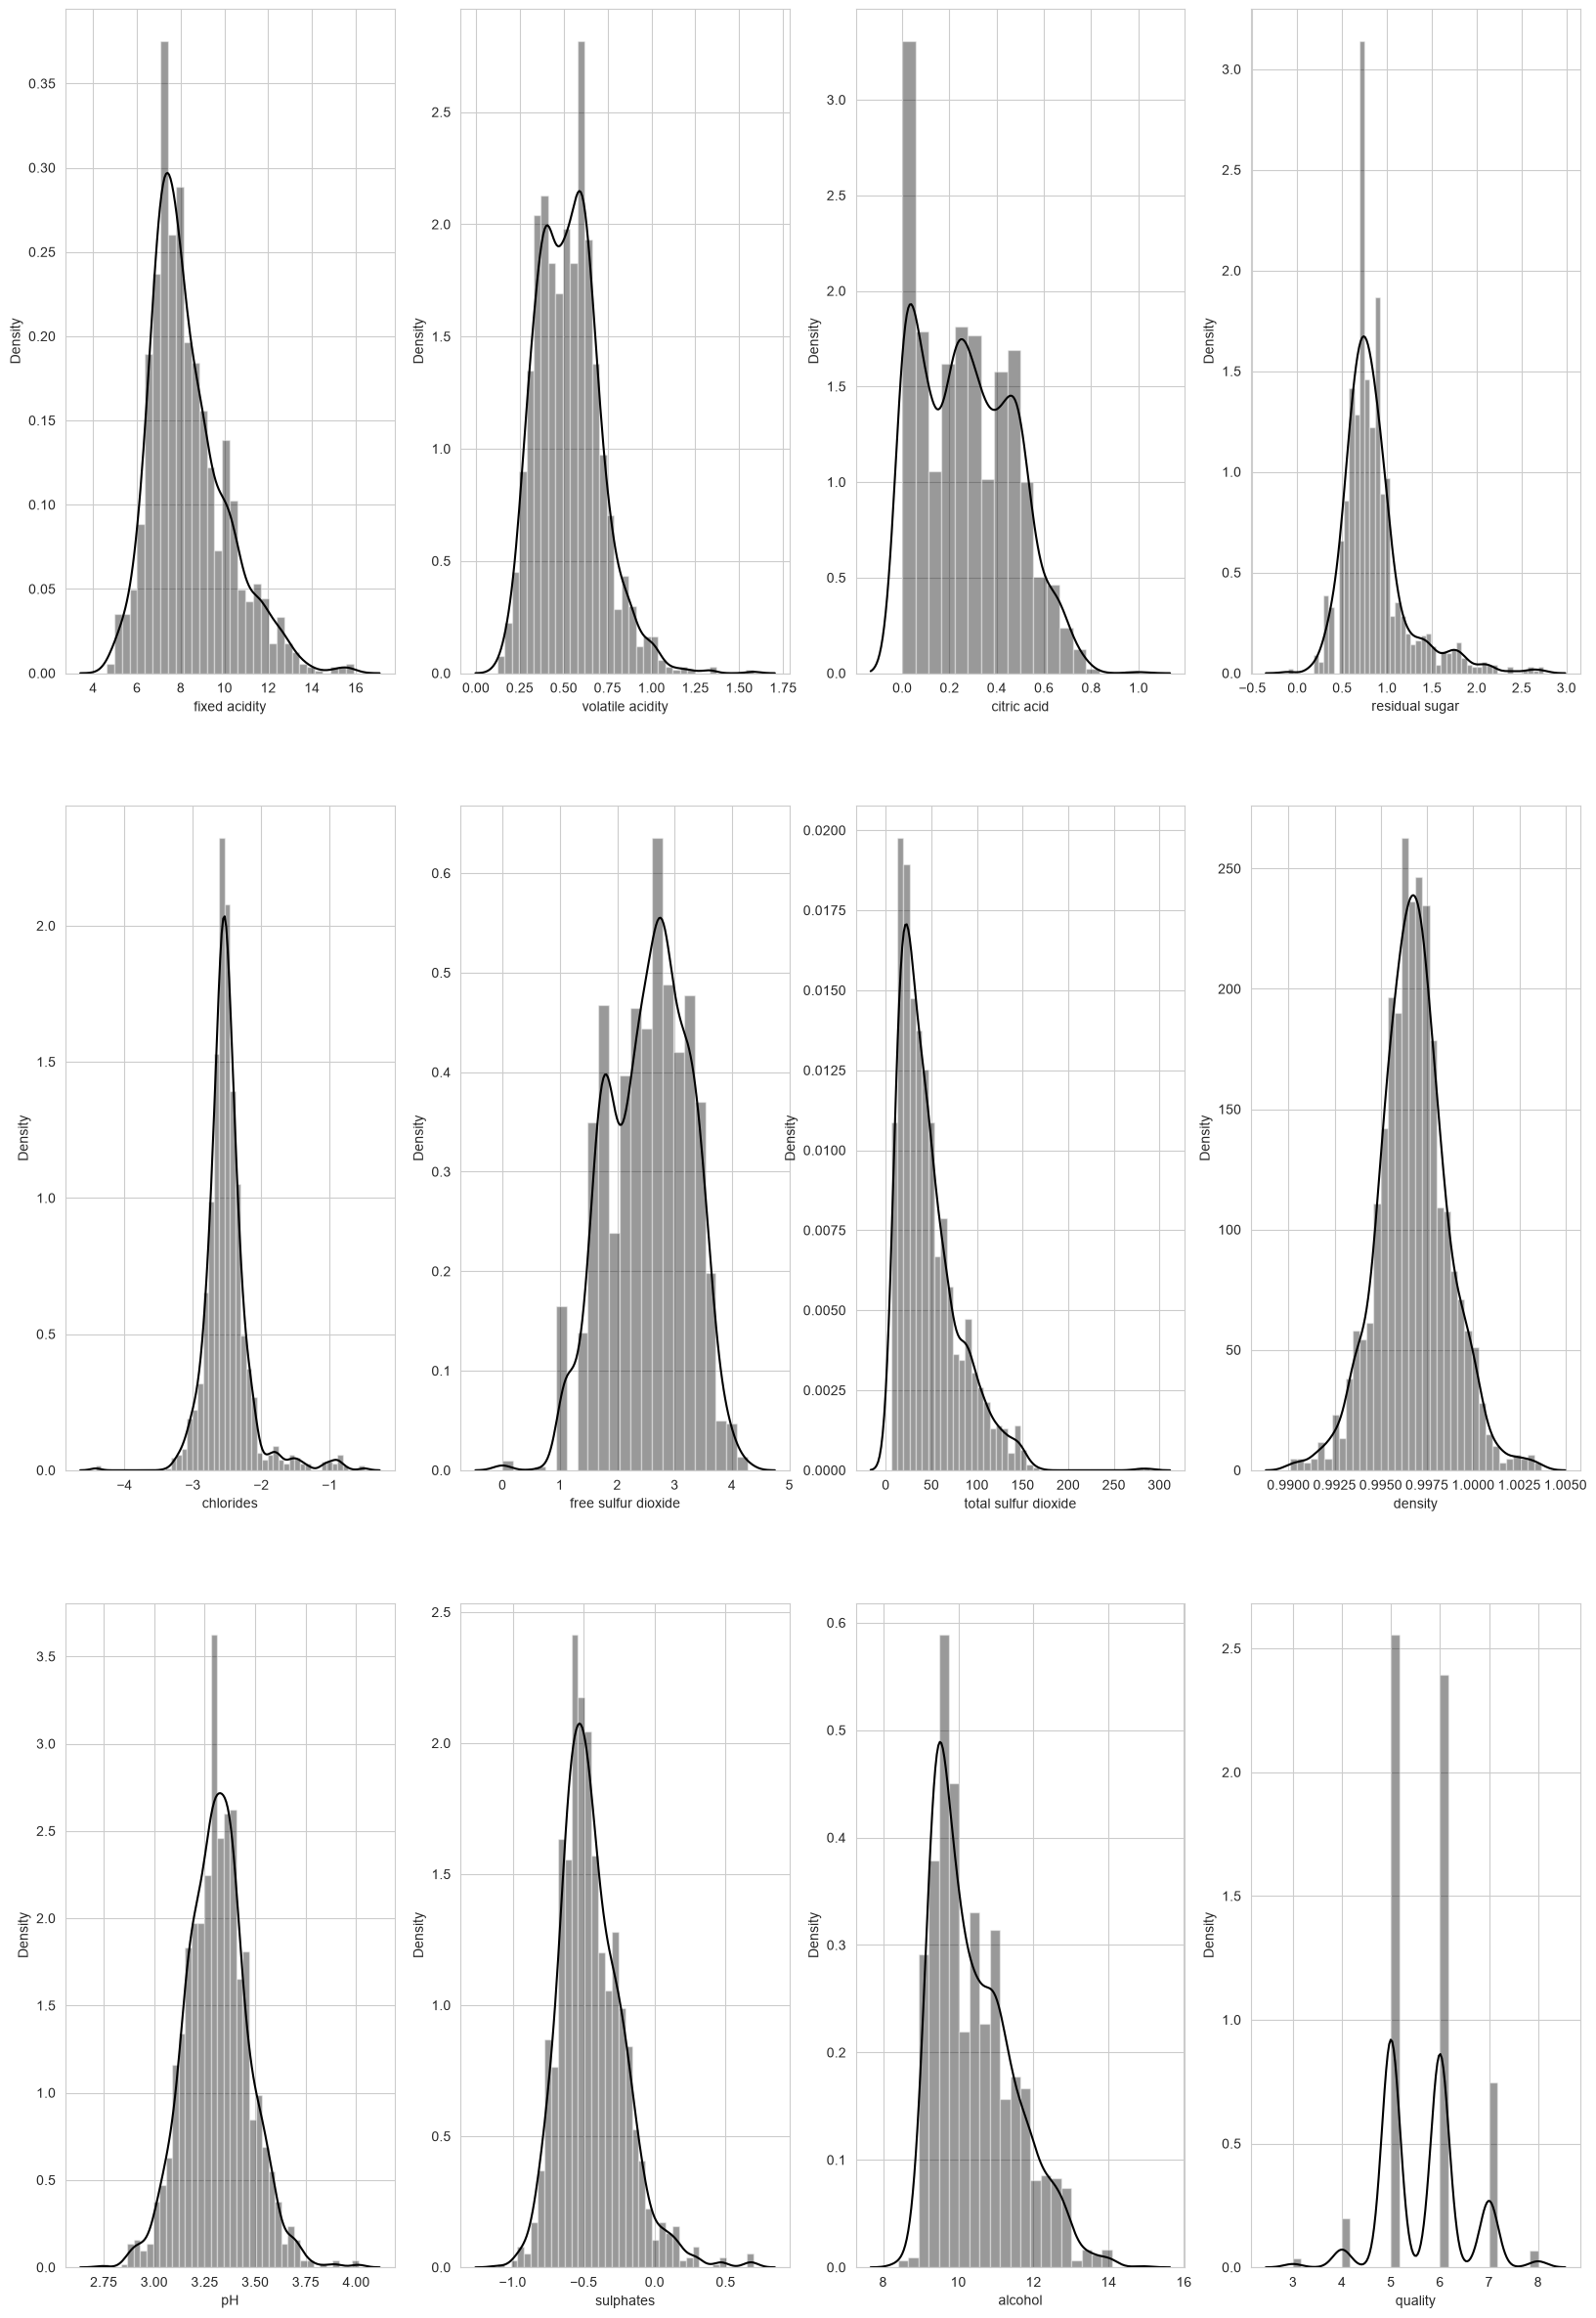

In [35]:
color=sns.color_palette('pastel')

fig,ax1=plt.subplots(3,4,figsize=(20,30))
k=0
columns=list(wdf.columns)
for i in range(3):
    for j in range(4):
     sns.distplot(wdf[columns[k]],ax=ax1[i][j],color='black')
     k=k+1
plt.show()

In [36]:
wdf.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.308642
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.023533
free sulfur dioxide    -0.050087
pH                     -0.057731
total sulfur dioxid    -0.170143
density                -0.174919
chlorides              -0.176140
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [37]:
#dataset split
x=wdf.drop(columns=['quality']) #x=independent variable
Y=wdf['quality'] #y=dependent

In [38]:
Y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [39]:
pip install imblearn


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Arbiya\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [41]:
from imblearn.over_sampling import SMOTE
oversample=SMOTE(k_neighbors=4)
x,Y=oversample.fit_resample(x.fillna(0),Y)

In [42]:
Y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split,cross_val_score

In [46]:
def classify(model,x,Y):
    x_train,x_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.2,random_state=9)
    model.fit(x_train,Y_train)
    return model.score(x_test,Y_test)*100

In [47]:
#applu logistic regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
LR_acc=classify(model,x,Y)
LR_acc

50.36674816625917

In [49]:
#apply RFC 
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier()
rf_acc=classify(model_rf,x,Y)
rf_acc


87.53056234718827

In [52]:
from sklearn.svm import SVC
model_svm=SVC()
svm_acc=classify(model_svm,x,Y)
svm_acc

38.386308068459655